# DATA ANALYSIS ON TITANIC SURVIVAL

# Literature review 
### source - https://www.redalyc.org/journal/6099/609964309005/html/

In [39]:
import pandas as pd 
df = pd.read_csv("Titanic-Dataset.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# key findings and data issues

### key findings 
-  Survival is highly dependent on gender
-  Passenger class (Pclass) matters a lot
-  Age plays a role
-  Fare correlates with survival
-  Family size impact (SibSp + Parch)

### Data issues 
- missing values ( incomlete data )
- unreliable feature ( bht null values hai useful pattern  nikalna mushkil )
- complex data ( ticket column)
- name ( extra info missing hai Mr , Mrs , Miss )
- outliers in numerical data 

---
# Most important features
### 1.sex 
- female - high chances of survival 
- male - low chances of survival 

### pclass(passenger class)
- 1 class - high survival (first priority)
- 3 class - low survival ( last priority )

### Fare 
- directly linked with pclass
- high fare ( rich people have high chances of survial because they are in first priority for better access to lifeboats )

### age 
- children have highest chances of survival
- elder persons have low chances

### embarked 
- from which port they entered 
- cherbourg (c)
- southampton ( S )
- Queenstown( Q )
---

In [40]:
# Shape of the dataset 
df.shape

(891, 12)

In [41]:
# checking duplicate values in different columns 

df.duplicated().sum()

0

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data issues 
- The full Name feature is not very useful, but extracting titles (Mr, Mrs, Miss, etc.) from it can provide meaningful insights.
- Cabin has 687 missing values, which is a very large number. Because of this, finding reliable patterns becomes difficult, making it one of the least useful features.
- The Age column contains missing values that should be filled because it is a very important and informative feature.
- Embarked also has missing values and should be handled since it is a useful column for analysis.
- Ticket numbers are mostly random and contain mixed information, so this feature is generally considered less useful.
- Age and Fare may contain many outliers, so they need to be handled carefully during preprocessing.
- New features can be created from the existing data, such as Title, FamilySize, IsAlone, and FarePerPerson, to improve analysis and model performance.

In [43]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# DATA CLEANING 

In [44]:
# Extract Title from Name column and create a new feature called "Title"

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Check first few rows
print(df[['Name', 'Title']].head())

                                                Name Title
0                            Braund, Mr. Owen Harris    Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs
2                             Heikkinen, Miss. Laina  Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs
4                           Allen, Mr. William Henry    Mr


In [45]:
# fill missing values in age with median 
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age']\
              .transform(lambda x: x.fillna(x.median()))

In [46]:
# Fill embarked with mode beacuse embarked is a categorical data 
df.fillna({'Embarked': df['Embarked'].mode()[0]}, inplace=True)

In [47]:
# Cabin me bahut zyada missing values hain (~77%)
# Isliye directly useful nahi hota
# Model me noise create kar sakta hai
# Remove Cabin column from dataset

df.drop('Cabin', axis=1, inplace=True)

# Check remaining columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'Title'],
      dtype='object')


In [48]:
# Remove Ticket column from dataset

df.drop('Ticket', axis=1, inplace=True)

# Check remaining columns
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked', 'Title'],
      dtype='object')


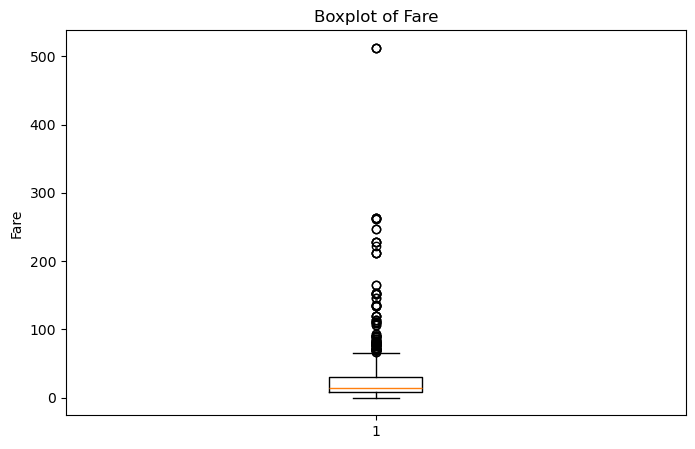

In [49]:
import matplotlib.pyplot as plt

# Boxplot for detecting outliers in Fare column

plt.figure(figsize=(8,5))
plt.boxplot(df['Fare'])

plt.title('Boxplot of Fare')
plt.ylabel('Fare')

plt.show()

In [50]:
# Removing extreme value in fare column 
df = df[df['Fare'] < 500]

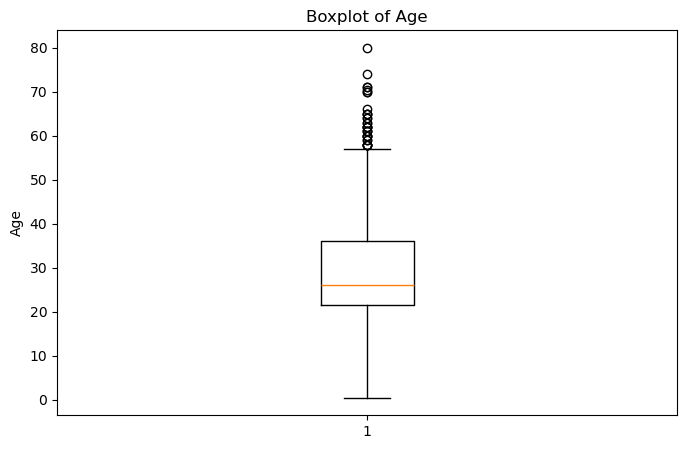

In [51]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Age'])

plt.title('Boxplot of Age')
plt.ylabel('Age')

plt.show()

isme hum outlier remove nahi karege kyuki titanic me 60 se upar ke log hona possible hai kuvh hi log hai jaada age ke jo ho sakte hai to yaha data me koi error nahi lagri to remove karna shi nahi hoga 

sorce for saying this - https://www.encyclopedia-titanica.org/titanic-ages/60.html

In [52]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 19, 35, 60, 100],
    labels=['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior']
)

In [53]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,Mr,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,Mrs,MiddleAge
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,Miss,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,Mrs,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,Mr,Adult


In [54]:
# creating new feature 
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [55]:
# fareperperson
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

In [56]:
# Drop PassengerId and Name columns
# Not that much useful and title feature already created 

df.drop(['PassengerId', 'Name'], axis=1, inplace=True)

# Check remaining columns
print(df.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'Title', 'AgeGroup', 'FamilySize', 'FarePerPerson'],
      dtype='object')


In [57]:
# new feature for identifying  is person alone or not 
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [58]:
# Drop SibSp and Parch

df.drop(['SibSp', 'Parch'], axis=1, inplace=True)


SibSp and Parch were removed after creating FamilySize and IsAlone features, since the engineered features captured the same information more effectively and reduced redundancy

In [59]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,AgeGroup,FamilySize,FarePerPerson,IsAlone
0,0,3,male,22.0,7.2500,S,Mr,Adult,2,3.62500,0
1,1,1,female,38.0,71.2833,C,Mrs,MiddleAge,2,35.64165,0
2,1,3,female,26.0,7.9250,S,Miss,Adult,1,7.92500,1
3,1,1,female,35.0,53.1000,S,Mrs,Adult,2,26.55000,0
4,0,3,male,35.0,8.0500,S,Mr,Adult,1,8.05000,1


# Data is cleand now and ready for analysis 

### UNIVARIATE ANALYSIS

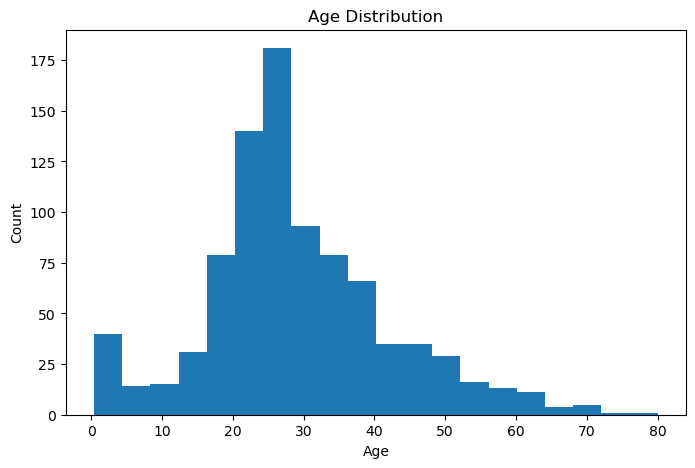

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=20)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

- iss graph se pata chalra hai ki kis age ke log jada hai  humare data me
- isme jaise hum dekh sakte hai mostly log 20-30 age group hai aur 60 ke baad log kaafi kum hai 
- aur 4-5 age tak ke bacche bhi kaafi hai 

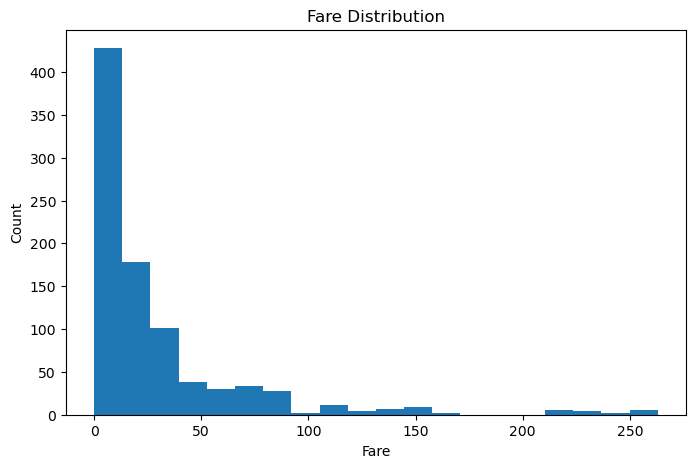

In [61]:
plt.figure(figsize=(8,5))
plt.hist(df['Fare'], bins=20)

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Count')

plt.show()

- Iss plot me dekh sakte hai ki jadatar logo ka fare price 0-40 me lie karra hai 
- mtlb ship mr aise log jaada hai jinka ticket price 50 se kamm hai hai aur unme jadatar lof 20-30 age group ke hai 

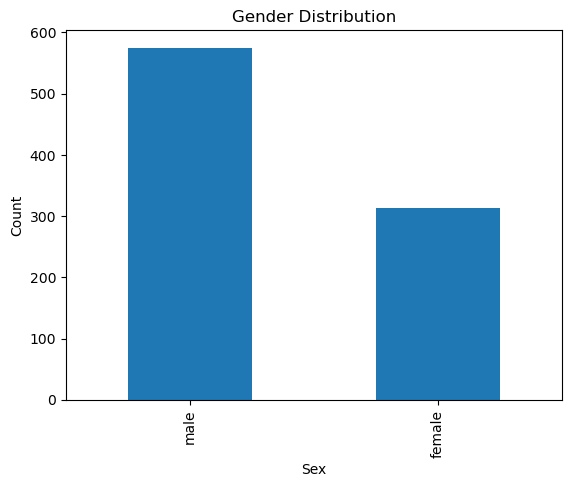

In [62]:
df['Sex'].value_counts().plot(kind='bar')

plt.title('Gender Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

is comparison me male bht jaada hai female ke comparioson me 

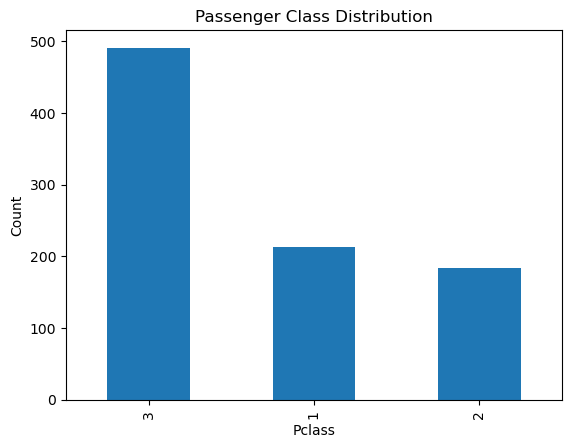

In [63]:
df['Pclass'].value_counts().plot(kind='bar')

plt.title('Passenger Class Distribution')
plt.xlabel('Pclass')
plt.ylabel('Count')

plt.show()

- abb isme dekh sake hai ki 3rd class ke log bht jada hai baaki do class ke comparison iss wajah se se inlogo ka jo fare price hai wo 50 se kaafi kam tha
- aur ye jo log the inme jadatar young log the 20-30 age group ke  

sabse jada log jo aaye the wo southampton ke the 

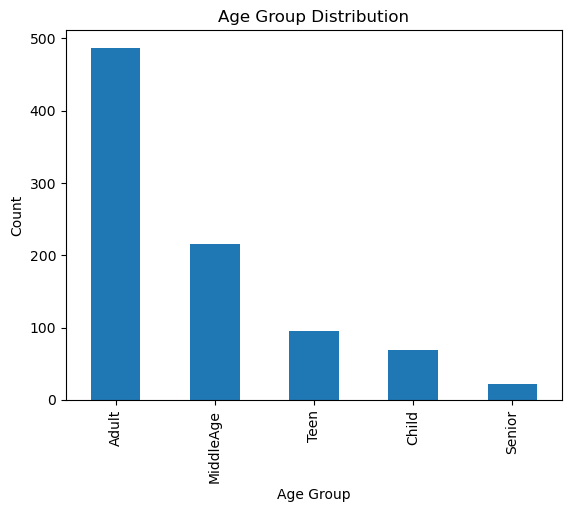

In [64]:
df['AgeGroup'].value_counts().plot(kind='bar')

plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.show()

## BIVARIATE ANALYSIS 

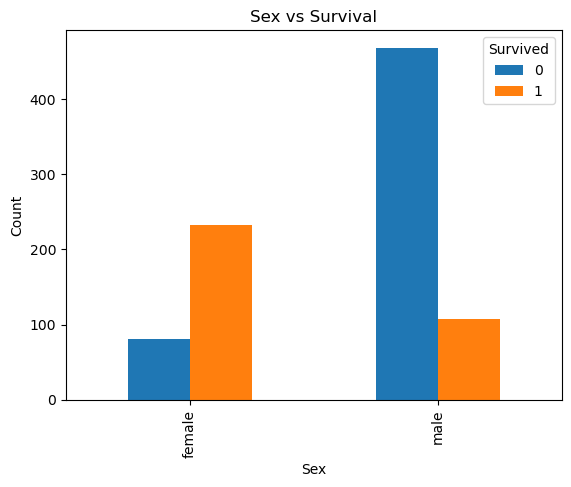

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar')

plt.title('Sex vs Survival')
plt.xlabel('Sex')
plt.ylabel('Count')

plt.show()

iss graph me hum dekh sakte hai ki total passengers me male almost female ke double the but jin logo ne survive kiya unme female ke count male ke double hai so hume yaha se ye pata chalta hai ki female ko first priority pe rakha gya tha safe karne ke liye 

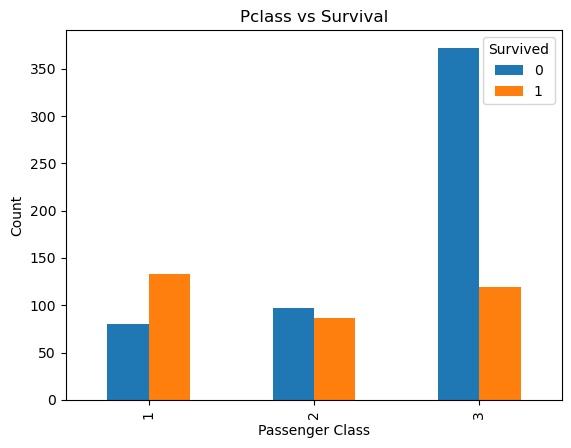

In [66]:
pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar')

plt.title('Pclass vs Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.show()

1,2,3 teeno class me jitne passengers the unme se sabse jada percentage survivors me 1st class ke log the jo bach gye the jabki 3rd class me around 25% log hi bach paye aur 

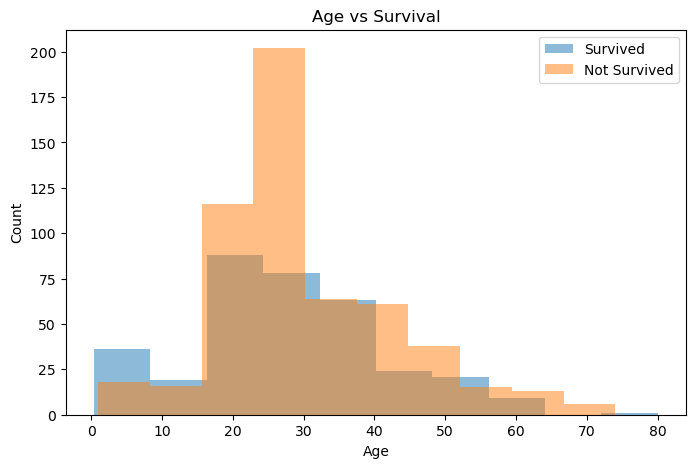

In [67]:
plt.figure(figsize=(8,5))

plt.hist(df[df['Survived']==1]['Age'], alpha=0.5, label='Survived')
plt.hist(df[df['Survived']==0]['Age'], alpha=0.5, label='Not Survived')

plt.legend()

plt.title('Age vs Survival')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

- sabse jada bachne wale aur marne waale dono young age ke the but marne wale logo survive karne walo se kaafi jaada the almost double 
- aur jo sanse jaada bache aur kmm mare wo children the 0-10 ki age wale bacche 

# MULTIVARIATE ANALYSIS 

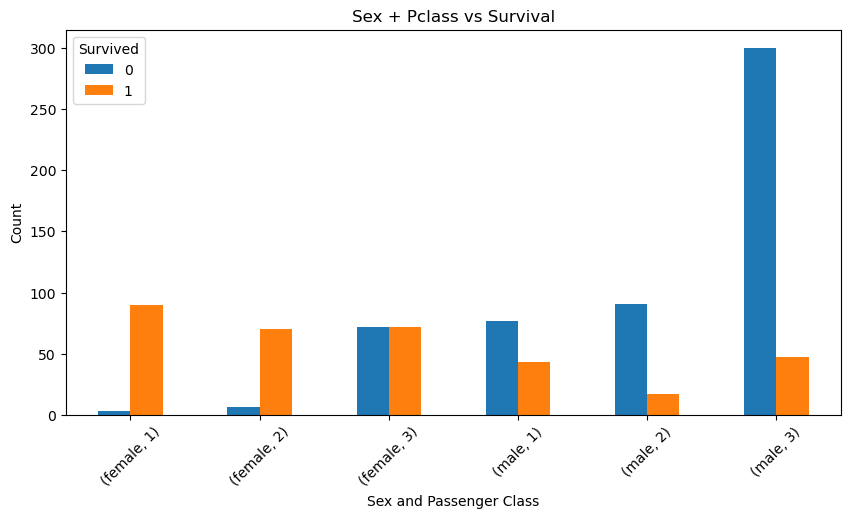

In [68]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab([df['Sex'], df['Pclass']], df['Survived']).plot(kind='bar', figsize=(10,5))

plt.title('Sex + Pclass vs Survival')
plt.xlabel('Sex and Passenger Class')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

### Pattern - ***Female passengers were given higher priority for survival, regardless of their passenger class. Women were rescued first . Even poor females survived better than many males.***

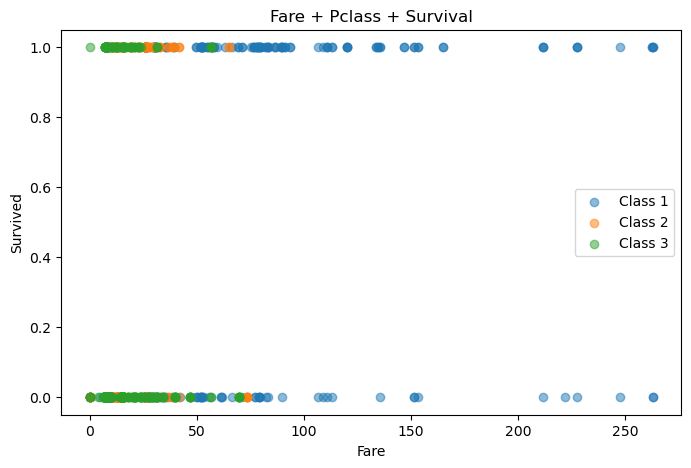

In [69]:
plt.figure(figsize=(8,5))

for cls in sorted(df['Pclass'].unique()):
    subset = df[df['Pclass'] == cls]
    plt.scatter(subset['Fare'], subset['Survived'], label=f'Class {cls}', alpha=0.5)

plt.legend()

plt.title('Fare + Pclass + Survival')
plt.xlabel('Fare')
plt.ylabel('Survived')

plt.show()

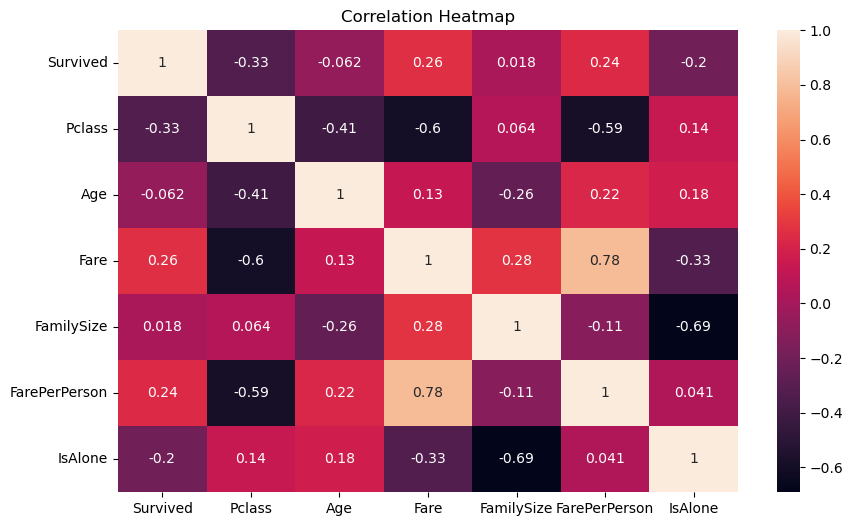

In [70]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title('Correlation Heatmap')

plt.show()

# DATASET INSIGHTS 
##### 1. The total number of passengers included around 300 females and 600 males. However, among the survivors, around 230 were females while the number of surviving males was very low, close to 100. This indicates that females were given higher priority for lifeboat access during the rescue process.


##### 2. Based on age distribution, the highest number of passengers belonged to the young age group. Among the survivors, younger passengers had a higher survival count, especially females. However, the number of people who did not survive was almost double the number of survivors, with males having a comparatively higher death count.


##### 3. Survival was also highly dependent on passenger class (Pclass). Wealthier passengers, mainly from 1st and 2nd class, had a much higher survival count, while passengers from lower classes had significantly lower survival rates.


##### 4. When analyzing Fare and Pclass together, most survivors belonged to 1st and 2nd class and had paid higher ticket fares compared to 3rd class passengers. This suggests that richer passengers had better survival opportunities.


##### 5. From the relationship between multiple features, we can observe that:

- Survival count and Pclass have a negative relationship (higher class number → lower survival).

- Survival count and Age also show a negative relationship (older passengers had lower survival chances).

- Survival count and Fare have a positive relationship (higher fare → higher survival chances).


## Overall Conclusion

- We can conclude that survival mainly depended on Age, Pclass, Fare, and Sex.


- Children, teenagers, and younger passengers had higher survival chances.


- Passengers from higher classes (1st and 2nd class) had better survival rates.


- Passengers who paid higher fares, generally wealthier individuals, had greater chances of survival.


- Female passengers had nearly double the survival count compared to males.



In [71]:
# FILE SAVING 
# Save cleaned dataset as CSV file

df.to_csv('Cleaned Titanic Dataset.csv', index=False)

print("File saved successfully!")

File saved successfully!
